# Results DHR26

**Table of contents**<a id='toc0_'></a>    
- 1. [Imports](#toc1_)    
- 2. [Load](#toc2_)    
- 3. [Convergence](#toc3_)    
  - 3.1. [Raw](#toc3_1_)    
  - 3.2. [Transfer](#toc3_2_)    
- 4. [Euler errors](#toc4_)    
- 5. [Life-cycle profiles](#toc5_)    
- 6. [Moments](#toc6_)    
  - 6.1. [Mean, median, var, skew, kurt](#toc6_1_)    
  - 6.2. [Correlations](#toc6_2_)    
  - 6.3. [Leverage constraint](#toc6_3_)    
- 7. [Calibration table](#toc7_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## 1. <a id='toc1_'></a>[Imports](#toc0_)

In [52]:
import sys
import os
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size':14})
plt.rcParams.update({'font.family':'serif'})

from LifeCycleModel import LifeCycleModelClass
from model_funcs import get_action 

In [53]:
parent_directory = os.path.abspath('..')
sys.path.append(parent_directory)
from plot_funcs import convergence_plot, compute_transfer

## 2. <a id='toc2_'></a>[Load](#toc0_)

In [54]:
folder_load = '../output/'
folder_save = '../output/results/nonconvex/'
model = LifeCycleModelClass(device='cpu',load=folder_load + 'LargeLifeCycleModel.pt')
model_backward = LifeCycleModelClass(device='cpu',load=folder_load + 'LargeLifeCycleModel_backward.pt')


To numpy:

for model in models:
    sim = models[model].sim
    for name in list(vars(sim)): 
        v = getattr(sim, name)
        if torch.is_tensor(v):
            setattr(sim, name, v.detach().cpu().numpy())

## 3. <a id='toc3_'></a>[Convergence](#toc0_)

### 3.1. <a id='toc3_1_'></a>[Raw](#toc0_)

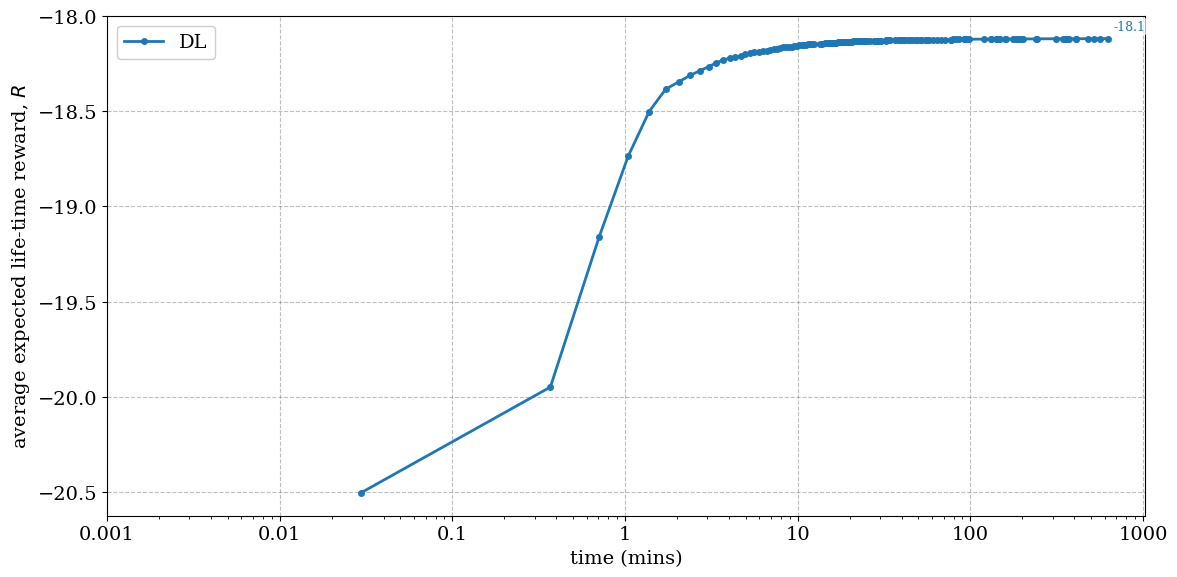

In [55]:
models = {'DL':model}
specs = {'DL':'DL'}
convergence_plot('LargeScaleLifeCycle',models,specs,DP=None,do_transfer=False,
                     xlim=None,ylim=None,legend_ncol=2,folder=folder_save,postfix='_average_reward',do_display=True)

### 3.2. <a id='toc3_2_'></a>[Transfer](#toc0_)

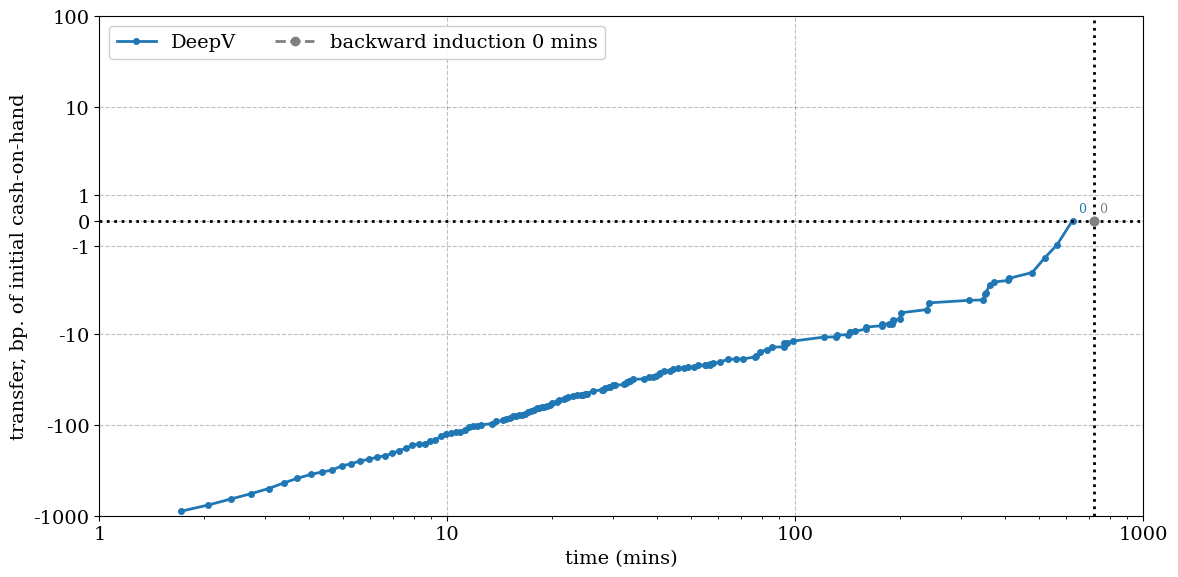

In [56]:
# a. backward
backward = {}
    
backward['t_beg'] = model.train.K_time
backward['t_end'] = backward['t_beg'] + model_backward.train.K_time

backward['transfer_beg'] = compute_transfer(model.sim.R_transfer,model.sim.transfer_grid,model.sim.R)
backward['transfer_end'] = compute_transfer(model_backward.sim.R_transfer,model.sim.transfer_grid,model_backward.sim.R)    

# c. plot
from types import SimpleNamespace
model.egm = SimpleNamespace()
model.egm.transfer_grid = model.sim.transfer_grid
model.egm.transfer_R = model.sim.R_transfer

models = {'DL': model}
specs = {'DL': 'DeepV'}

convergence_plot('LargeScaleLifeCycle',models,specs,
                 backward=backward,
                 DP=model,DP_name='',xlim=(1,1000),do_transfer=True,folder=folder_save,postfix='_transfer_equivalent')

## 4. <a id='toc4_'></a>[Euler errors](#toc0_)

Euler errors == 0 is 2 of 1567820


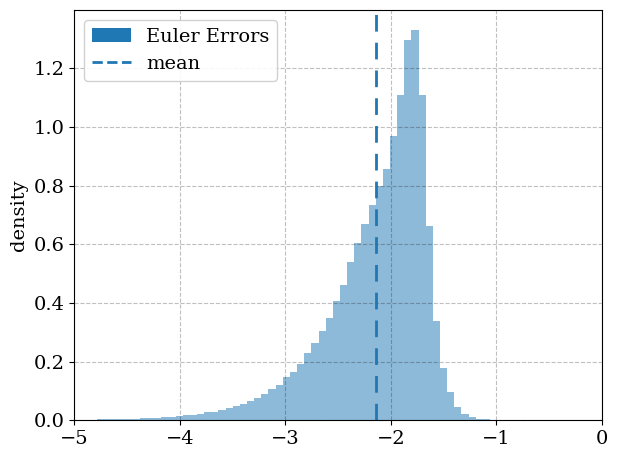

In [57]:
# a. Euler errors
unconstrained = model.sim.unconstrained[:-1].flatten().cpu().numpy()
euler_errors = np.abs(model.sim.euler_error[:-1].flatten().cpu().numpy())
euler_errors = euler_errors[unconstrained]
share_zero = np.sum(euler_errors == 0.0)
print(f'Euler errors == 0 is {share_zero} of {euler_errors.size}')
euler_errors = euler_errors[euler_errors > 0.0]
euler_errors = np.log10(euler_errors)

# b. plot

fig,ax = plt.subplots()

# i. histogram
ax.hist(euler_errors,bins=100,density=True,color=colors[0],alpha=0.5,label='Euler Errors')

# ii. means
mean = float(np.nanmean(euler_errors))
ax.axvline(mean,color=colors[0],linestyle='--',linewidth=2,dashes=(6,4))

# iii. details
ax.set_ylabel('density')
ax.set_xlim(-5.0,0.0)

legend_elements = [
    Patch(facecolor=colors[0],edgecolor='none',label='Euler Errors'),
    Line2D([0],[0],color=colors[0],lw=2,ls='--',label='mean'),
]
ax.legend(handles=legend_elements,loc='upper left',frameon=True,framealpha=0.9)

# iv. save
plt.tight_layout()
plt.savefig(folder_save + 'LargeLifeCycle_euler_errors.svg')

## 5. <a id='toc5_'></a>[Life-cycle profiles](#toc0_)

In [58]:
# a. states
a = model.sim.states[:,:,0].cpu().numpy()
b = model.sim.states[:,:,1].cpu().numpy()
e = model.sim.states[:,:,2].cpu().numpy()
w = model.sim.states[:,:,3].cpu().numpy()
p = model.sim.states[:,:,4].cpu().numpy()
h = model.sim.states[:,:,5].cpu().numpy()
m = model.sim.states[:,:,6].cpu().numpy()

# b. decisions

# i. discrete choices
DC = model.sim.DC.cpu().numpy()
par = model.par 

iDC_work = np.array([i for i,choice in enumerate(par.iDC_from_choices) if 'work' in choice])
iDC_adj = np.array([i for i,choice in enumerate(par.iDC_from_choices) if 'adjust' in choice])
iDC_renter = np.array([i for i,choice in enumerate(par.iDC_from_choices) if 'renter' in choice])
iDC_owner = np.array([i for i,choice in enumerate(par.iDC_from_choices) if 'owner' in choice])
iDC_buyer = np.array([i for i,choice in enumerate(par.iDC_from_choices) if 'buyer' in choice])

work = np.isin(DC,iDC_work)
adj = np.isin(DC,iDC_adj)
renter = np.isin(DC,iDC_renter)
owner = np.isin(DC,iDC_owner)
buyer = np.isin(DC,iDC_buyer)

## ii. continous
actions = model.sim.actions.cpu().numpy() 
outcomes = model.sim.outcomes.cpu().numpy()

savings = np.zeros_like(a)
portfolio_share = np.zeros_like(a)
housing_share = np.zeros_like(a)
leverage = np.zeros_like(a) 

a_pd = np.zeros_like(a)
b_pd = np.zeros_like(a)
consumption = np.zeros_like(a)
coh = np.zeros_like(a)
ell = np.zeros_like(a)
m_pd = np.zeros_like(a)
h_pd = np.zeros_like(a)

h_tilde = np.zeros_like(a)  # housing flow consumption 

par = model.par 
for i_DC in range(par.NDC):

    work_DC,portfolio_DC,housing_DC = list(par.choices_from_iDC[i_DC].values())

    # o. unpacking actions
    savings += get_action(i_DC,'savings',actions,par)*(DC==i_DC)
            
    if portfolio_DC=='adj':
        portfolio_share += get_action(i_DC,'risky_share',actions,par)*(DC==i_DC)
    
    if housing_DC=='buyer':
        housing_share += get_action(i_DC,'housing_share',actions,par)*(DC==i_DC)
        leverage += get_action(i_DC,'leverage',actions,par)*(DC==i_DC)

    # o. unpacking outcomes
    a_pd += outcomes[...,0,i_DC]*(DC==i_DC)
    b_pd += outcomes[...,1,i_DC]*(DC==i_DC)
    consumption += outcomes[...,2,i_DC]*(DC==i_DC)
    coh += outcomes[...,3,i_DC]*(DC==i_DC)
    ell += outcomes[...,4,i_DC]*(DC==i_DC)
    h_pd += outcomes[...,5,i_DC]*(DC==i_DC)
    m_pd += outcomes[...,6,i_DC]*(DC==i_DC)
    h_tilde += outcomes[...,7,i_DC]*(DC==i_DC)

In [59]:
iDC_work = np.array([i for i,choice in enumerate(par.iDC_from_choices) if 'work' in choice])
iDC_adj = np.array([i for i,choice in enumerate(par.iDC_from_choices) if 'adjust' in choice])
iDC_renter = np.array([i for i,choice in enumerate(par.iDC_from_choices) if 'renter' in choice])
iDC_owner = np.array([i for i,choice in enumerate(par.iDC_from_choices) if 'owner' in choice])
iDC_buyer = np.array([i for i,choice in enumerate(par.iDC_from_choices) if 'buyer' in choice])

work = np.isin(DC,iDC_work)
adj = np.isin(DC,iDC_adj)
renter = np.isin(DC,iDC_renter)
owner = np.isin(DC,iDC_owner)
buyer = np.isin(DC,iDC_buyer)

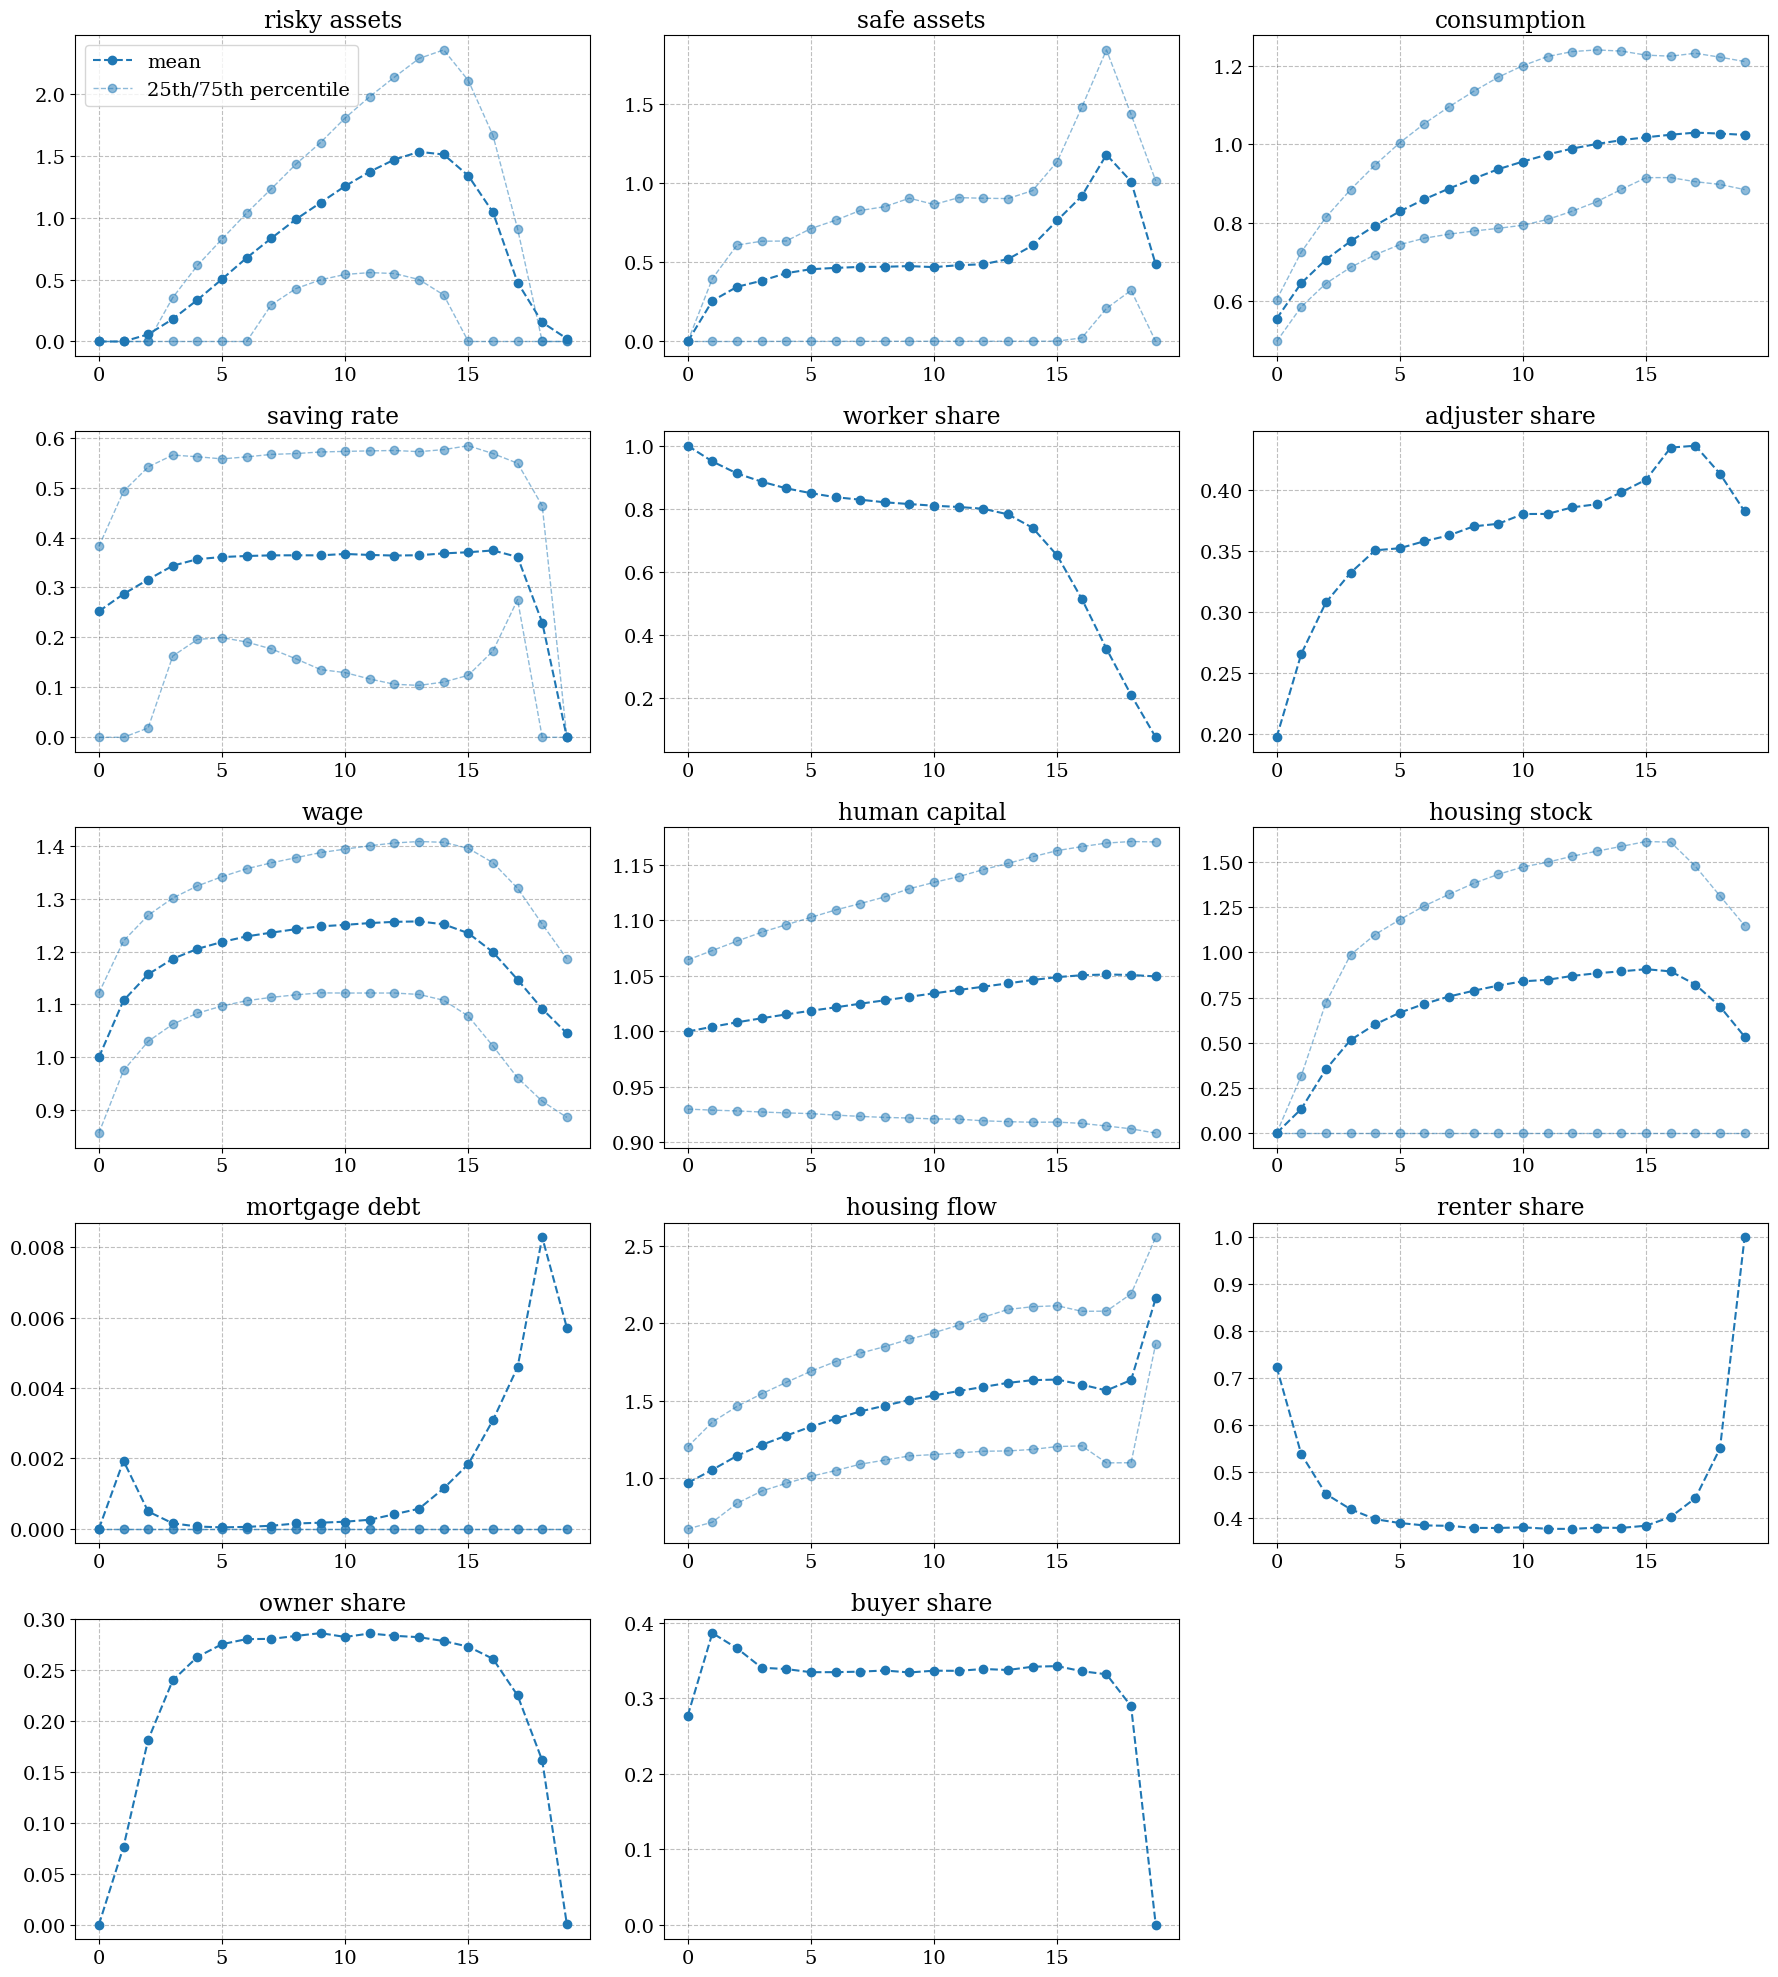

In [60]:
def plot_with_iqr_lines(ax,arr,color,ls='--',marker=None):
    '''
    Plot mean and 25th/75th percentile bounds as lines.
    arr: array with shape (T,N),time on axis 0,cross-section on axis 1.
    '''

    t = np.arange(arr.shape[0])
    mean = np.mean(arr,axis=1)
    p25  = np.percentile(arr,25,axis=1)
    p75  = np.percentile(arr,75,axis=1)

    ax.plot(t,mean,color=color,ls=ls,marker=marker,label='mean')
    ax.plot(t,p25,color=color,lw=1,ls=ls,marker=marker,alpha=0.5,label='25th/75th percentile')
    ax.plot(t,p75,color=color,lw=1,ls=ls,marker=marker,alpha=0.5)

ls = '--'
marker='o'
fig,axs = plt.subplots(5,3,figsize=(3*6,5*4))

# 1) Risky assets
plot_with_iqr_lines(axs[0,0],a,colors[0],ls='--',marker='o')
axs[0,0].set_title('risky assets')
axs[0,0].legend()

# 2) Safe assets
plot_with_iqr_lines(axs[0,1],b,colors[0],ls='--',marker='o')
axs[0,1].set_title('safe assets')

# 3) Consumption
plot_with_iqr_lines(axs[0,2],consumption,colors[0],ls='--',marker='o')
axs[0,2].set_title('consumption')

# 4) Saving rate
plot_with_iqr_lines(axs[1,0],savings,colors[0],ls='--',marker='o')
axs[1,0].set_title('saving rate')

# 5) Worker share
axs[1,1].plot(work.mean(axis=1),ls=ls,marker=marker)
axs[1,1].set_title('worker share')

# 6) Adjuster share
axs[1,2].plot(adj.mean(axis=1),ls=ls,marker=marker)
axs[1,2].set_title('adjuster share')

# 7) Wage
plot_with_iqr_lines(axs[2,0],w,colors[0],ls='--',marker='o')
axs[2,0].set_title('wage')

# 8) Human capital
plot_with_iqr_lines(axs[2,1],p,colors[0],ls='--',marker='o')
axs[2,1].set_title('human capital')

# 9) Housing stock
plot_with_iqr_lines(axs[2,2],h,colors[0],ls='--',marker='o')
axs[2,2].set_title('housing stock')

# 10) Mortgage debt
plot_with_iqr_lines(axs[3,0],m,colors[0],ls='--',marker='o')
axs[3,0].set_title('mortgage debt')

# 11) Housing flow
plot_with_iqr_lines(axs[3,1],h_tilde,colors[0],ls='--',marker='o')
axs[3,1].set_title('housing flow')

# 12) Renter share
axs[3,2].plot(renter.mean(axis=1),ls=ls,marker=marker)
axs[3,2].set_title('renter share')

# 13) Owner share
axs[4,0].plot(owner.mean(axis=1),ls=ls,marker=marker)
axs[4,0].set_title('owner share')

# 14) Buyer share
axs[4,1].plot(buyer.mean(axis=1),ls=ls,marker=marker)
axs[4,1].set_title('buyer share')

# Empty subplot (optional: remove if you want a cleaner 14-panel grid)
axs[4,2].axis('off')

plt.tight_layout()
plt.savefig(folder_save + 'LargeLifeCycle_lcps.svg')
plt.show()

## 6. <a id='toc6_'></a>[Moments](#toc0_)

### 6.1. <a id='toc6_1_'></a>[Mean, median, var, skew, kurt](#toc0_)

In [62]:
ts = [1,9,14,19]

def _moments_nanrobust(A,fallback=True):
    '''
    Row-wise mean,median,skew,kurt (non-excess; normal => 3).
    Handles NaNs. If fallback=True,when std==0 or n<3: skew=0,kurt=3.
    '''

    T,N = A.shape
    mu    = np.full(T,np.nan)
    med   = np.full(T,np.nan)
    skew  = np.full(T,np.nan)
    kurt  = np.full(T,np.nan)

    for t in range(T):
        x = A[t]
        m = np.isfinite(x)
        n = m.sum()
        if n == 0:
            if fallback: kurt[t] = 3.0; skew[t] = 0.0
            continue

        xm = x[m]
        mu[t]  = np.mean(xm)
        med[t] = np.median(xm)
        s = np.std(xm,ddof=0)

        if s > 0 and n >= 3:
            z = (xm - mu[t]) / s
            skew[t] = np.mean(z**3)
            kurt[t] = np.mean(z**4)      # non-excess kurtosis
        elif fallback:
            skew[t] = 0.0
            kurt[t] = 3.0
    
    var = np.var(A,axis=1)

    return mu,med,var,skew,kurt

def _extract_vars(sim):

    out = {}

    # portfolio
    out['a'] = sim.states[:,:,0].cpu().numpy()
    out['b'] = sim.states[:,:,1].cpu().numpy()
    
    # job ladder
    out['e'] = sim.states[:,:,2].cpu().numpy()
    out['w'] = sim.states[:,:,3].cpu().numpy()
    out['p'] = sim.states[:,:,4].cpu().numpy()
    
    # housing block
    out['h'] = sim.states[:,:,5].cpu().numpy()
    out['m'] = sim.states[:,:,6].cpu().numpy()
    
    # outcomes
    out['c'] = sim.c.cpu().numpy()
    
    return out

def get_moments_table(model,ts=[0,4,9,14,19]):        

    vars_list = ['a','b','c','h','m','w','p']
    moment_names = ['Mean','Median','Variance','Skewness','Kurtosis']

    # rows: (variable,moment)
    rows = pd.MultiIndex.from_product(
        [vars_list,moment_names],
        names=['var','moment']
    )

    # columns: use simple Index (not MultiIndex) to avoid tuple formatting
    cols = pd.Index(ts,name='t')

    table = pd.DataFrame(index=rows,columns=cols,dtype=float)

    sim_vars = _extract_vars(model.sim)

    for vname in vars_list:
        mu,med,var_,sk,ku = _moments_nanrobust(sim_vars[vname])

        moments = {
            'Mean': mu,
            'Median': med,
            'Variance': var_,
            'Skewness': sk,
            'Kurtosis': ku,
        }

        for t in ts:
            for mname,arr in moments.items():
                table.loc[(vname,mname),t] = arr[t]

    return table

In [63]:
def table_to_latex_nice(df,filepath,decimals=3,longtable=False,do_print=False):
    r"""
    Export a MultiIndex-row DataFrame (like your full table) to LaTeX with booktabs.
    - Pretty time headers ($t=\cdot$)
    - One \midrule before the 'Correlations' block
    - No horizontal rules inside the correlations block
    """

    # a. headers like $t=0,9,14,...$
    df_out = df.copy()
    df_out.columns = [f"$t={c}$" for c in df.columns]

    # b. float formatting and simple right-aligned columns
    float_fmt = ("{:.%df}" % decimals).format
    colfmt = "ll" + "r" * df_out.shape[1]   # two index columns + numeric columns

    if do_print: display(df_out.style.format(float_fmt))  # show the DataFrame in the notebook before exporting

    latex = df_out.to_latex(
        buf=None,
        escape=False,          # keep math ($\cdot$) in row labels
        index_names=True,
        bold_rows=False,
        na_rep="",
        float_format=float_fmt,
        column_format=colfmt,
        multicolumn=True,
        multirow=True,
        longtable=longtable,
        header=True,
    )

    # c. add a \midrule just before the "Correlations" row, and remove rules inside that block
    if ("Correlations","") in df_out.index:

        lines = latex.splitlines()

        # find first 'Correlations &' row
        corr_idx = None
        for i,ln in enumerate(lines):
            if ln.strip().startswith("Correlations &"):
                corr_idx = i
                break

        if corr_idx is not None:
            # insert a \midrule right before the correlations header if not already there
            if corr_idx == 0 or not lines[corr_idx-1].strip().startswith(r"\midrule"):
                lines.insert(corr_idx,r"\midrule")
                corr_idx += 1  # correlations header shifted down by 1

            # remove any rules *inside* the correlations block up to \bottomrule
            j = corr_idx + 1
            while j < len(lines):
                s = lines[j].strip()
                if s.startswith(r"\bottomrule"):
                    break
                if s.startswith(r"\hline") or s.startswith(r"\midrule") or s.startswith(r"\cline"):
                    lines.pop(j)   # drop rule line and continue without advancing
                else:
                    j += 1

            # compact accidental empty lines
            latex = "\n".join(l for l in lines if l != "")

    latex = latex.replace(
        "\\begin{tabular}",
        "\\centering\n\\footnotesize\n\\setlength\\tabcolsep{4pt}\n"
        "\\renewcommand\\arraystretch{1.15}\n\\begin{tabular}"
    )

    with open(filepath,"w",encoding="utf-8") as f:
        f.write(latex)

In [64]:
table_to_latex_nice(get_moments_table(model,ts=ts),
                    folder_save+'LargeLifeCycle_moments.tex',decimals=3,longtable=False,do_print=True)

### 6.2. <a id='toc6_2_'></a>[Correlations](#toc0_)

In [65]:
def keep_upper_triangle(table,prefix='Corr',var_order=None):

    idx = table.index.to_series()
    pat = rf'^{prefix}\(([^,]+),\s*([^)]+)\)$'
    is_pair = idx.str.match(pat)
    pairs = idx.str.extract(pat)

    order = {v:i for i,v in enumerate(var_order)}
    lx = pairs[0].map(lambda v: order.get(v,np.inf))
    ly = pairs[1].map(lambda v: order.get(v,np.inf))
    keep = is_pair & (lx < ly)

    out = table[~is_pair | keep].copy()

    # normalize labels to x<y
    new_labels = out.index.to_series()
    norm = pairs.loc[keep]
    new_labels.loc[keep.index[keep]] = norm[0].astype(str) + "," + norm[1].astype(str)
    out.index = np.where(
        keep.loc[out.index.to_series().index].fillna(False),
        f"{prefix}(" + new_labels + ")",out.index
    )
    return out

def get_correlations_table(model,ts):

    vars_ = ['a','b','c','h','m','w','p']
    cols = pd.Index(ts,name='t')  # standardize column name
    table = pd.DataFrame(index=[],columns=cols,dtype=float)

    df = _extract_vars(model.sim)
    for v1 in vars_:
        for v2 in vars_:
            if v1 == v2:
                continue
            for t in ts:
                rho = np.corrcoef(df[v1][t],df[v2][t])[0,1]
                table.loc[f"Corr({v1},{v2})",t] = rho

    # keep only upper triangle,then up-cast to MultiIndex compatible with moments
    table = keep_upper_triangle(table,prefix='Corr',
                                var_order=('a','b','c','h','m','w','p'))
    return table

In [66]:
def table_to_latex_correlations(df_corr,filepath,decimals=3,longtable=False,do_print=False):

    """LaTeX for correlations; adds spacing between Corr(a,·) / Corr(b,·) / ... groups."""
    df_out = df_corr.copy()
    
    # make headers nice
    df_out.index = df_out.index.set_names(("Correlation"))
    df_out.columns = [f"$t={c}$" for c in df_out.columns]

    float_fmt = ("{:.%df}" % decimals).format
    colfmt = "ll" + "r" * df_out.shape[1]

    latex = df_out.to_latex(
        buf=None,
        escape=False,
        index_names=True,
        bold_rows=False,
        na_rep="",
        float_format=float_fmt,
        column_format=colfmt,
        multicolumn=True,
        multirow=True,
        longtable=longtable,
        header=True,
    )

    # --- post-process ---
    import re
    lines = latex.splitlines()

    # 1) drop lines that draw partial rules
    lines = [ln for ln in lines
             if not ln.lstrip().startswith(r"\cline")
             and not ln.lstrip().startswith(r"\cmidrule")]

    # 2) insert \addlinespace on group change Corr(x,·) -> Corr(y,·)
    pat_first = re.compile(r'^\s*Corr\(\s*([^,]+)\s*,')   # capture first var
    prev_first = None
    i = 0
    while i < len(lines):
        ln = lines[i]
        if ln.lstrip().startswith(r"\bottomrule"):
            break
        m = pat_first.match(ln)
        if m:
            first = m.group(1)
            if prev_first is None:
                prev_first = first
            elif first != prev_first:
                # insert spacer before this row
                lines.insert(i,r"\addlinespace")
                i += 1
                prev_first = first
        i += 1

    latex = "\n".join(lines)
    latex = latex.replace(
        "\\begin{tabular}",
        "\\centering\n\\footnotesize\n\\setlength\\tabcolsep{4pt}\n"
        "\\renewcommand\\arraystretch{1.15}\n\\begin{tabular}"
    )
    with open(filepath,"w",encoding="utf-8") as f:
        f.write(latex)
    if do_print:
        print(latex)


In [67]:
table_to_latex_correlations(get_correlations_table(model,ts=ts),
                             folder_save+'LargeLifeCycle_correlations.tex',decimals=3,longtable=False,do_print=True)

\centering
\footnotesize
\setlength\tabcolsep{4pt}
\renewcommand\arraystretch{1.15}
\begin{tabular}{llrrrr}
\toprule
 & $t=1$ & $t=9$ & $t=14$ & $t=19$ \\
Correlation &  &  &  &  \\
\midrule
Corr(a,b) & 0.079 & 0.012 & 0.090 & -0.096 \\
Corr(a,c) & 0.058 & 0.661 & 0.634 & 0.122 \\
Corr(a,h) & -0.014 & 0.175 & 0.172 & -0.058 \\
Corr(a,m) & -0.003 & 0.013 & 0.090 & 0.416 \\
Corr(a,w) & 0.081 & 0.496 & 0.455 & -0.010 \\
Corr(a,p) & 0.018 & 0.299 & 0.303 & 0.001 \\
\addlinespace
Corr(b,c) & 0.115 & 0.110 & 0.177 & 0.178 \\
Corr(b,h) & -0.762 & -0.614 & -0.327 & -0.735 \\
Corr(b,m) & -0.179 & -0.012 & -0.010 & -0.067 \\
Corr(b,w) & 0.182 & 0.075 & 0.013 & 0.020 \\
Corr(b,p) & 0.078 & 0.089 & 0.235 & 0.092 \\
\addlinespace
Corr(c,h) & 0.238 & 0.409 & 0.405 & 0.350 \\
Corr(c,m) & -0.004 & -0.027 & 0.000 & 0.064 \\
Corr(c,w) & 0.561 & 0.686 & 0.632 & 0.127 \\
Corr(c,p) & 0.469 & 0.382 & 0.376 & 0.308 \\
\addlinespace
Corr(h,m) & 0.175 & -0.015 & -0.005 & 0.055 \\
Corr(h,w) & 0.197 & 0.279 & 0.

### 6.3. <a id='toc6_3_'></a>[Leverage constraint](#toc0_)


In [68]:
# Verify leverage constraint: m <= llambda * p_h * h
par = model.par

# Get post-decision housing and mortgage from the simulation
h_pd_sim = h_pd  # housing post-decision (already extracted above)
m_pd_sim = m_pd  # mortgage post-decision (already extracted above)

# Compute the maximum allowed mortgage under the leverage constraint
max_mortgage = par.llambda * par.p_h * h_pd_sim

# Check constraint violation (with small tolerance for numerical errors)
tol = 1e-6
constraint_violated = m_pd_sim > max_mortgage + tol

# Report results
n_violations = constraint_violated.sum()
n_total = constraint_violated.size
violation_rate = n_violations / n_total * 100

print(f"Leverage constraint: m <= {par.llambda:.2f} * {par.p_h:.2f} * h")
print(f"=" * 50)
print(f"Total observations: {n_total:,}")
print(f"Violations: {n_violations:,} ({violation_rate:.4f}%)")

if n_violations > 0:
    # Show worst violations
    violation_amounts = (m_pd_sim - max_mortgage)[constraint_violated]
    print(f"\nWorst violation: m exceeds max by {violation_amounts.max():.6f}")
    print(f"Mean violation amount: {violation_amounts.mean():.6f}")
    
    # Show which periods have violations
    violations_by_t = constraint_violated.sum(axis=1)
    print(f"\nViolations by period:")
    for t in range(len(violations_by_t)):
        if violations_by_t[t] > 0:
            print(f"  t={t}: {violations_by_t[t]} violations")
else:
    print("\nLeverage constraint is satisfied for all agents in the simulation.")

Leverage constraint: m <= 0.90 * 1.00 * h
Total observations: 2,000,000
Violations: 0 (0.0000%)

Leverage constraint is satisfied for all agents in the simulation.


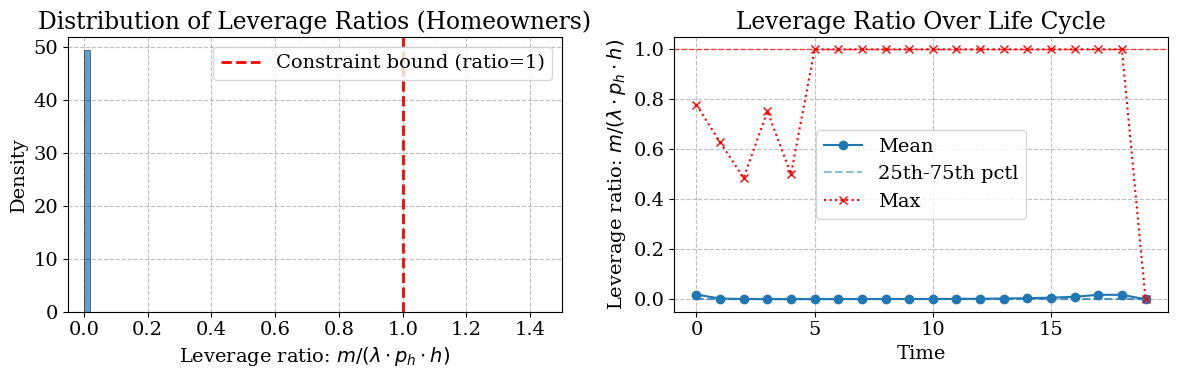


Summary statistics for leverage ratio (homeowners only):
  Mean: 0.0040
  Median: 0.0000
  Max: 0.9990
  Share at constraint (ratio > 0.99): 0.05%


In [69]:
# Plot the distribution of leverage ratios (m / (llambda * p_h * h))
# Only for homeowners (h > 0)

homeowners_mask = h_pd_sim > 1e-6
leverage_ratio = np.zeros_like(m_pd_sim)
leverage_ratio[homeowners_mask] = m_pd_sim[homeowners_mask] / (par.llambda * par.p_h * h_pd_sim[homeowners_mask])

# Flatten for histogram (only homeowners with positive housing)
leverage_flat = leverage_ratio[homeowners_mask].flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of leverage ratios
ax = axes[0]
ax.hist(leverage_flat, bins=50, density=True, alpha=0.7, color=colors[0], edgecolor='black', linewidth=0.5)
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Constraint bound (ratio=1)')
ax.set_xlabel('Leverage ratio: $m / (\\lambda \\cdot p_h \\cdot h)$')
ax.set_ylabel('Density')
ax.set_title('Distribution of Leverage Ratios (Homeowners)')
ax.legend()
ax.set_xlim(-0.05, 1.5)

# Right: leverage ratio over the life cycle
ax = axes[1]
mean_leverage_by_t = np.array([leverage_ratio[t, homeowners_mask[t]].mean() if homeowners_mask[t].sum() > 0 else np.nan for t in range(leverage_ratio.shape[0])])
p25_leverage_by_t = np.array([np.percentile(leverage_ratio[t, homeowners_mask[t]], 25) if homeowners_mask[t].sum() > 0 else np.nan for t in range(leverage_ratio.shape[0])])
p75_leverage_by_t = np.array([np.percentile(leverage_ratio[t, homeowners_mask[t]], 75) if homeowners_mask[t].sum() > 0 else np.nan for t in range(leverage_ratio.shape[0])])
max_leverage_by_t = np.array([leverage_ratio[t, homeowners_mask[t]].max() if homeowners_mask[t].sum() > 0 else np.nan for t in range(leverage_ratio.shape[0])])

t_vec = np.arange(leverage_ratio.shape[0])
ax.plot(t_vec, mean_leverage_by_t, color=colors[0], marker='o', label='Mean')
ax.plot(t_vec, p25_leverage_by_t, color=colors[0], alpha=0.5, linestyle='--', label='25th-75th pctl')
ax.plot(t_vec, p75_leverage_by_t, color=colors[0], alpha=0.5, linestyle='--')
ax.plot(t_vec, max_leverage_by_t, color='red', marker='x', linestyle=':', label='Max')
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Leverage ratio: $m / (\\lambda \\cdot p_h \\cdot h)$')
ax.set_title('Leverage Ratio Over Life Cycle')
ax.legend()

plt.tight_layout()
plt.savefig(folder_save + 'LargeLifeCycle_leverage_constraint.svg')
plt.show()

print(f"\nSummary statistics for leverage ratio (homeowners only):")
print(f"  Mean: {np.nanmean(leverage_flat):.4f}")
print(f"  Median: {np.nanmedian(leverage_flat):.4f}")
print(f"  Max: {np.nanmax(leverage_flat):.4f}")
print(f"  Share at constraint (ratio > 0.99): {(leverage_flat > 0.99).mean()*100:.2f}%")

## 7. <a id='toc7_'></a>[Calibration table](#toc0_)

In [70]:
par=model.par
col_index=pd.Index(['Parameter','Value','Description','Source'])
new_rows=[

    # Preferences
    {'Parameter':r'\textit{Householdspreferences}','Value':'','Description':'','Source':''},
    {'Parameter':r'\(T\)','Value':par.T,'Description':'Maximumlifetime','Source':''},
    {'Parameter':r'\(\sigma\)','Value':par.sigma,'Description':'CRRA','Source':''},
    {'Parameter':r'\(\beta\)','Value':par.beta,'Description':'Discountfactor','Source':''},
    {'Parameter':r'\(\alpha\)','Value':par.alpha,'Description':'Cobb-Douglasconsumptionpreferenceshare','Source':''},
    {'Parameter':'','Value':'','Description':'','Source':''},
    
    # Jobladder
    {'Parameter':r'\textit{Jobladder}','Value':'','Description':'','Source':''},
    {'Parameter':r'\(\pi^{e}\)','Value':par.pi_job_find,'Description':'Job-findingprobability','Source':''},
    {'Parameter':r'\(\delta^{e}\)','Value':par.pi_job_loss,'Description':'Job-lossprobability','Source':''},
    {'Parameter':r'\(\sigma^{w}\)','Value':par.sigma_w,'Description':'Stddev.ofjoboffers','Source':''},
    {'Parameter':r'\(\chi^u\)','Value':par.chi_b,'Description':'Unemployment-benefitsparameters','Source':''},
    {'Parameter':r'\(\bar{u}\)','Value':par.b_bar,'Description':'Maximumunemployment-benefits','Source':''},
    {'Parameter':r'\(\mu^{pe},\mu^{pu}\)','Value':(par.mu_p_e,par.mu_p_u),'Description':'Meanhumancapitalaccumulation','Source':''},
    {'Parameter':r'\(\underline{p}\)','Value':par.p_min,'Description':'Lowerboundonhumancapital','Source':''},
    {'Parameter':'','Value':'','Description':'','Source':''},
    
    # Portfolioblock
    {'Parameter':r'\textit{Portfolio}','Value':'','Description':'','Source':''},
    {'Parameter':r'\(\sigma^r\)','Value':par.ra_sigma,'Description':'Std.dev.ofriskyreturns','Source':''},
    {'Parameter':r'\(\kappa=\mathbb{E}[r_t^a]-r^b\)','Value':par.r-par.rb,'Description':'Equitypremium','Source':''},
    {'Parameter':r'\(F\)','Value':par.F,'Description':'Fixedcostofportfoliochoice','Source':''},
    {'Parameter':'','Value':'','Description':'','Source':''},
    
    # Housingblock
    {'Parameter':r'\textit{Housing}','Value':'','Description':'','Source':''},
    {'Parameter':r'\(\tau^h\)','Value':par.tau_h,'Description':'Adjustmentcostonhousing','Source':''},
    {'Parameter':r'\(\tau^L\)','Value':par.tau_m,'Description':'Adjustmentcostonmortgages','Source':''},
    {'Parameter':r'\(\lambda^h\)','Value':par.llambda,'Description':'1-downpaymentshare','Source':''},
    {'Parameter':r'\(r^m\)','Value':par.r_m,'Description':'Mortgageinterestrate','Source':''},
    {'Parameter':r'\(\phi\)','Value':par.rent_price_ratio,'Description':'Rent-to-priceratio','Source':''},
]

df = pd.DataFrame(new_rows,columns=col_index)

df.round(2)

,Parameter,Value,Description,Source
0,\textit{Householdspreferences},,,
1,\(T\),20,Maximumlifetime,
2,\(\sigma\),2,CRRA,
3,\(\beta\),0.904762,Discountfactor,
4,\(\alpha\),0.8875,Cobb-Douglasconsumptionpreferenceshare,
5,,,,
6,\textit{Jobladder},,,
7,\(\pi^{e}\),0.2,Job-findingprobability,
8,\(\delta^{e}\),0.05,Job-lossprobability,
9,\(\sigma^{w}\),0.2,Stddev.ofjoboffers,


In [71]:
latex = df.to_latex(
        buf=None,
        escape=False,
        index=False,
        index_names=False,
        bold_rows=False,
        na_rep="",
        multicolumn=False,
        multirow=False,
        header=True,
        float_format="%.2f"
    )


latex = latex.replace(
    "\\begin{tabular}",
    "\\centering\n\\footnotesize\n\\setlength\\tabcolsep{4pt}\n"
    "\\renewcommand\\arraystretch{1.15}\n\\begin{tabular}"
)
with open(folder_save + 'LargeLifeCycleModel_calibration.tex', "w", encoding="utf-8") as f:
    f.write(latex)